In [1]:
import sys
import numpy as np
import anndata as ad

import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

In [3]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

In [4]:
me_class = pl.read_csv('private/newest/late_meth_cl_spec_lfc2.csv')
me_class

name,n,clusters
str,i64,str
"""14-3-3epsilon""",3,"""Fat Body;Midgut;Muscle"""
"""18w""",3,"""Epidermis;Fat Body;Muscle"""
"""4E-T""",2,"""Muscle;Ventral Nerve Cord"""
"""AANATL2""",3,"""Epidermis;Muscle;Ventral Nerve…"
"""AANATL4""",1,"""Ventral Nerve Cord"""
…,…,…
"""wor""",2,"""Epidermis;Muscle"""
"""z""",4,"""Epidermis;Fat Body;Muscle;Vent…"
"""zen""",5,"""Epidermis;Fat Body;Midgut;Musc…"


In [5]:
rna_change = pl.read_excel('private/data/snrna_difex_MAST_per_clusters_251117_all.xlsx', sheet_id=0)
rna_change.keys()

dict_keys(['Neuronal 1', 'Epidermis', 'Muscle somatic', 'Yolk', 'Midgut', 'Fat Body', 'Tracheal', 'Glia', 'Plasmatocytes', 'Muscle visceral', 'Neuronal 2', 'Salivary Gland', 'Epidermis head', 'Sense', 'Glia lateral', 'Amnioserosa', 'Bristle'])

In [6]:
#active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
#muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
#muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

In [7]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

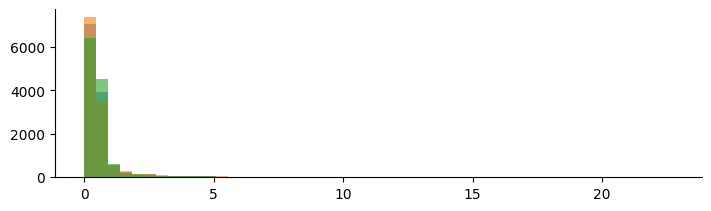

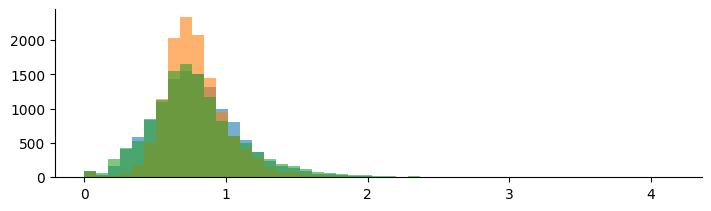

In [8]:
from src.tools._layers import get_layer_feature_means

acet_means = {}
meth_means = {}
a = list(cttag.obs['label'].cat.categories)
for c in a:
    means = get_layer_feature_means(cttag[cttag.obs['label'] == c], lc_acet)
    acet_means[c] = pl.DataFrame({'name': cttag.uns['gene_names_acet'], 'mean': means})#.write_csv('private/data/acet_means_muscle.csv')

    means = get_layer_feature_means(cttag[cttag.obs['label'] == c], lc_meth)
    meth_means[c] = pl.DataFrame({'name': cttag.uns['gene_names_acet'], 'mean': means})#.write_csv('private/data/meth_means_muscle.csv')

acet_means_muscle = acet_means['Muscle']
meth_means_muscle = meth_means['Muscle']
acet_means_vnc = acet_means['Ventral Nerve Cord']
meth_means_vnc = meth_means['Ventral Nerve Cord']
acet_means_epi = acet_means['Epidermis']
meth_means_epi = meth_means['Epidermis']

scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram([meth_means_muscle['mean'].to_numpy(),meth_means_vnc['mean'].to_numpy(),meth_means_epi['mean'].to_numpy()])
scit.pl.int.histogram([acet_means_muscle['mean'].to_numpy(),acet_means_vnc['mean'].to_numpy(),acet_means_epi['mean'].to_numpy()])



In [9]:
pl.DataFrame({k:v['mean'] for k,v in meth_means.items()} | {'name': cttag.uns['gene_names_acet']}).write_csv('private/newest/late_methylation.csv')

In [10]:
METH_TH = 2
ONLY_UPREG = False

import scipy.stats as sts

def c_df(k, change_group, _acet_mean, _meth_mean):
    df = rna_change[k]
    if ONLY_UPREG:
        df = df.filter(pl.col('avg_log2FC')>0)#.filter(pl.col('p_val')<0.01)#.filter(pl.col('p_val_adj')<0.05
    df = df.join(_acet_mean, left_on='gene_name',right_on='name',suffix='_acet').join(_meth_mean, left_on='gene_name',right_on='name', suffix='_meth')
    df = df.with_columns(pl.col('mean').alias('mean_acet'), (-np.log10(pl.col('p_val')).alias('ppval')))
    df = df.with_columns(
        (pl.col('ppval') * (pl.col('avg_log2FC'))).alias('score') #
    )

    _meth_change = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('group') == change_group)).with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    )
    _acet_change = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('group') == change_group)).with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    )
    df = df.join(_meth_change.rename({'score': 'lfc', 'pval': 'p_val'}).drop('group')
                 , left_on='gene_name',right_on='name',suffix='_mechange')
    df = df.join(_acet_change.rename({'score': 'lfc', 'pval': 'p_val'}).drop('group')
                 , left_on='gene_name',right_on='name',suffix='_acetchange')
    df = df.filter(pl.col('mean_meth')>METH_TH)
    df = df.with_columns(
        (df['avg_log2FC'].rank()).alias('regulation_rank'),
         (df['score'].rank()).alias('score_rank'),
        (df['ppval'].rank()).alias('ppval_rank'),
    )
    return df


In [11]:
np.intersect1d(
    rna_change['Muscle somatic']['gene_name'].to_numpy(),
    meth_means_muscle.filter(pl.col('mean')>2)['name'].to_numpy()
).shape

(228,)

In [12]:
#df_muscle = c_df('Muscle somatic', 'Muscle', acet_means_muscle, meth_means_muscle)
df_muscle = c_df('Muscle somatic', 'Ventral Nerve Cord', acet_means_muscle, meth_means_muscle)
# df_vnc = c_df('Neuronal 1', acet_means_vnc, meth_means_vnc)
# df_epi = c_df('Epidermis', acet_means_epi, meth_means_epi)
df_muscle

gene_name,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean,mean_meth,mean_acet,ppval,score,p_val_mechange,lfc,base_mean,ppval_mechange,p_val_acetchange,lfc_acetchange,base_mean_acetchange,ppval_acetchange,regulation_rank,score_rank,ppval_rank
str,f64,f64,f64,f64,f64,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""snRNP-U1-C""",0.113148,1.061698,0.022,0.011,1.0,1.142479,2.380877,1.142479,0.946352,1.004739,0.89559,0.391442,0.8232808,0.047891,0.6746346,0.429558,1.0799077,0.170931,165.0,153.0,105.0
"""opa""",0.369574,-0.833694,0.006,0.013,1.0,1.031063,17.051292,1.031063,0.432299,-0.360405,1.0,-0.236732,14.148252,-0.0,0.137137,-0.360127,1.0051531,0.862846,25.0,57.0,51.0
"""E(spl)mgamma-HLH""",0.002997,3.053925,0.018,0.003,1.0,0.982533,7.807286,0.982533,2.523242,7.705791,0.589609,0.42306,1.9040552,0.229436,1.0,-0.049785,0.5868681,-0.0,219.0,208.0,179.0
"""mod(mdg4)""",0.049373,0.388421,0.088,0.064,1.0,0.993179,3.928625,0.993179,1.306515,0.507477,0.785856,0.349638,3.7983136,0.104657,1.0,0.071685,1.0062077,-0.0,111.0,139.0,130.0
"""CG11920""",0.000002,4.810741,0.022,0.001,0.02793,0.931474,5.337224,0.931474,5.738423,27.606067,1.0,0.025044,6.1129246,-0.0,0.8705723,0.2904364,1.0501819,0.060195,224.0,224.0,220.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Actbeta""",0.000658,-7.322786,0.0,0.012,1.0,0.901391,2.11639,0.901391,3.181632,-23.298412,0.2660566,0.58491,1.6084396,0.575026,0.497473,-0.276621,1.3911223,0.303231,1.0,1.0,189.0
"""zfh2""",0.038249,-0.295442,0.033,0.049,1.0,1.134652,14.210262,1.134652,1.41738,-0.418754,1.0,0.146326,4.419922,-0.0,0.00003,-1.984371,1.8894022,4.519219,73.0,52.0,139.0
"""myo""",0.031153,0.269446,0.137,0.103,1.0,1.582895,5.193419,1.582895,1.506505,0.405922,1.0,0.216775,2.3697479,-0.0,0.681166,-0.262581,0.7982333,0.166747,105.0,137.0,145.0


In [13]:
def get_label(column: str):
    return str(column)
    # if 'acet' in column or 'meth' in column:
    #     return column
    # labl = ''
    # if 'rank' in column:
    #      labl += (' rank' if not ONLY_UPREG else ' upregulation rank')
    # return ("-log10(pval)*snRNA-seqFC(mut/wt)" if 'score' in column else "snRNA-seqFC(mut/wt)") + labl


def plot_scatters(
        df, log_transform=True,corr_use_minmax=False,rna_column: str = 'score',
        xminmax: tuple = None, qymax=True, qs=(0.995,0.995)
    ):

    size = 3
    alpha=1
    t = lambda x: x
    if log_transform:
        t = lambda x: np.log1p(x)

    for i, tit in enumerate(['acet', 'meth']):
        
        _df = df.with_columns(pl.col('mean_'+tit).alias('mean'))
        xy = np.c_[_df[rna_column].to_numpy(),t(_df['mean'].to_numpy())]

        yminmax=None
        if qymax:
            yminmax=(-0.01,np.quantile(xy[:,1],qs[i]))

        scit.pl.int.scatter(
            xy, s=size, alpha=alpha,c_map=[_df['ppval_rank']],
             ylabel=f'WT {tit} mean',
            xlabel=get_label(rna_column),
            yminmax=yminmax,xminmax=xminmax,corr='spearman',corr_use_minmax=corr_use_minmax,title=tit
        )

    
    xy = np.c_[t(df['mean_acet'].to_numpy()),t(df['mean_meth'].to_numpy())]

    scit.pl.int.scatter(
        xy, s=size, alpha=alpha,
        corr='spearman',corr_use_minmax=corr_use_minmax
    )


def qts(df, q: list[int],tit:str, x_column: str, y_column, color='tab:red', log_transform = False):
    _m = df[x_column].to_numpy()
    qs = []
    prev = 0
    prev_dat = 0
    ls = []
    t = lambda x: x
    # if log_transform:
    #     t = lambda x: np.log1p(x)
    
    for _q in q:
        q_dat = np.quantile(_m,0.01*_q)
        v = df.filter(pl.col(x_column)<q_dat).filter(pl.col(x_column)>=prev_dat)[y_column].to_numpy()
        ls.append(f'[{prev}, {_q})')
        #ls.append(f'({prev_dat},{q_dat})')
        qs.append(t(v))
        prev_dat = q_dat
        prev = _q
    

    stat = scit.tl.statistic_test(qs, [(0,j+1) for j in range(len(qs)-1)], test_type='ttest', welch=True)
    return scit.pl.int.boxplot(
        qs,
        ls,
        xlabel=get_label(x_column),
        ylabel=get_label(y_column),
        stat=stat,
        color=color,
        title=tit,show=False,write_n=True
    )

In [15]:
df_muscle

gene_name,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean,mean_meth,mean_acet,ppval,score,p_val_mechange,lfc,base_mean,ppval_mechange,p_val_acetchange,lfc_acetchange,base_mean_acetchange,ppval_acetchange,regulation_rank,score_rank,ppval_rank
str,f64,f64,f64,f64,f64,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""snRNP-U1-C""",0.113148,1.061698,0.022,0.011,1.0,1.142479,2.380877,1.142479,0.946352,1.004739,0.89559,0.391442,0.8232808,0.047891,0.6746346,0.429558,1.0799077,0.170931,165.0,153.0,105.0
"""opa""",0.369574,-0.833694,0.006,0.013,1.0,1.031063,17.051292,1.031063,0.432299,-0.360405,1.0,-0.236732,14.148252,-0.0,0.137137,-0.360127,1.0051531,0.862846,25.0,57.0,51.0
"""E(spl)mgamma-HLH""",0.002997,3.053925,0.018,0.003,1.0,0.982533,7.807286,0.982533,2.523242,7.705791,0.589609,0.42306,1.9040552,0.229436,1.0,-0.049785,0.5868681,-0.0,219.0,208.0,179.0
"""mod(mdg4)""",0.049373,0.388421,0.088,0.064,1.0,0.993179,3.928625,0.993179,1.306515,0.507477,0.785856,0.349638,3.7983136,0.104657,1.0,0.071685,1.0062077,-0.0,111.0,139.0,130.0
"""CG11920""",0.000002,4.810741,0.022,0.001,0.02793,0.931474,5.337224,0.931474,5.738423,27.606067,1.0,0.025044,6.1129246,-0.0,0.8705723,0.2904364,1.0501819,0.060195,224.0,224.0,220.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Actbeta""",0.000658,-7.322786,0.0,0.012,1.0,0.901391,2.11639,0.901391,3.181632,-23.298412,0.2660566,0.58491,1.6084396,0.575026,0.497473,-0.276621,1.3911223,0.303231,1.0,1.0,189.0
"""zfh2""",0.038249,-0.295442,0.033,0.049,1.0,1.134652,14.210262,1.134652,1.41738,-0.418754,1.0,0.146326,4.419922,-0.0,0.00003,-1.984371,1.8894022,4.519219,73.0,52.0,139.0
"""myo""",0.031153,0.269446,0.137,0.103,1.0,1.582895,5.193419,1.582895,1.506505,0.405922,1.0,0.216775,2.3697479,-0.0,0.681166,-0.262581,0.7982333,0.166747,105.0,137.0,145.0


data list 0 correlation result: SignificanceResult(statistic=np.float64(-0.27014027630040904), pvalue=np.float64(3.569322370903009e-05))


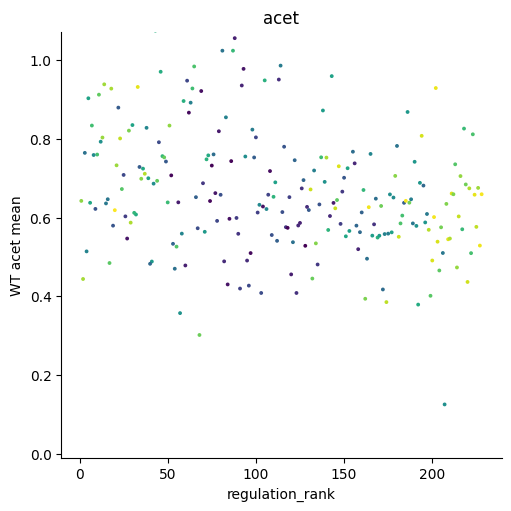

data list 0 correlation result: SignificanceResult(statistic=np.float64(-0.06715361797639877), pvalue=np.float64(0.3127041184050588))


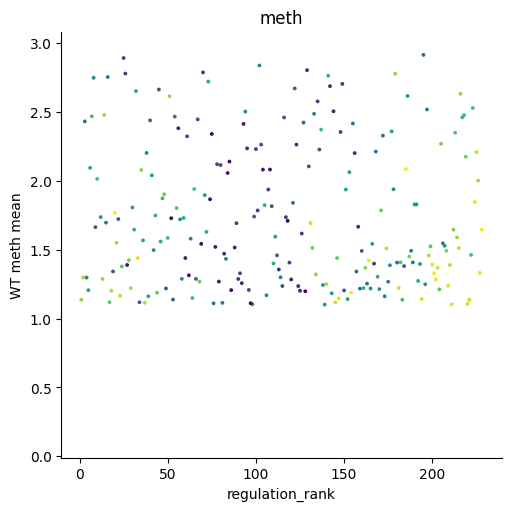

data list 0 correlation result: SignificanceResult(statistic=np.float64(0.09720864515586868), pvalue=np.float64(0.143407668519468))


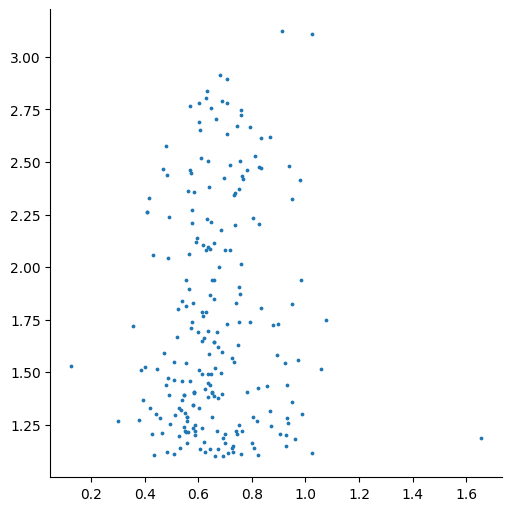

In [15]:

scit.set_defaults(figsize=(5,5))
plot_scatters(df_muscle, rna_column='regulation_rank')

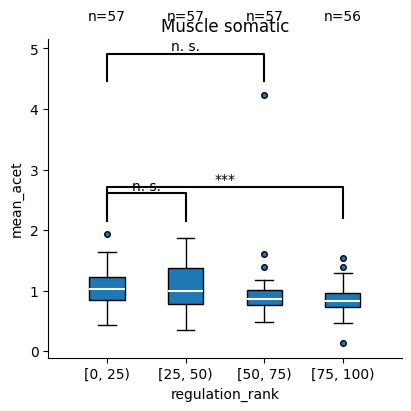

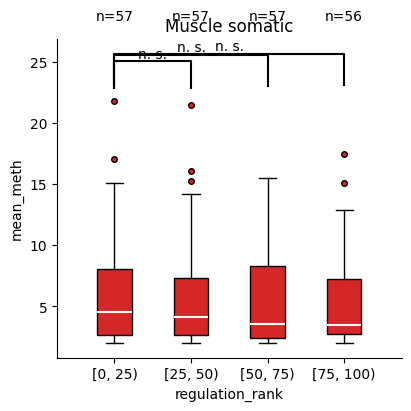

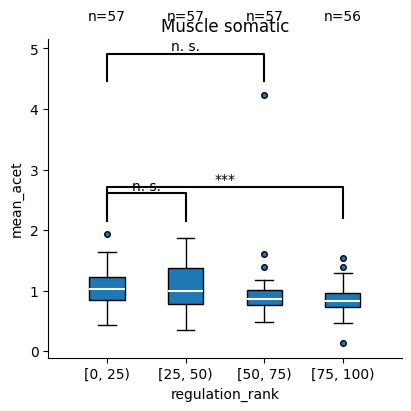

In [16]:
scit.set_defaults(figsize=(4,4))
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_meth', x_column='regulation_rank')#.savefig('private/newest/figures/muscle_meth_rnaLFC.pdf')
#qts(df_vnc, [25, 50, 75, 100], 'VNC', y_column='mean_meth', x_column='regulation_rank').savefig('/tmp/trash.pdf')

scit.set_defaults(figsize=(4,4))
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_acet', x_column='regulation_rank', color='tab:blue')#.savefig('private/newest/figures/muscle_acet_rnaLFC.pdf')
#qts(df_vnc, [25, 50, 75, 100], 'VNC', y_column='mean_acet', x_column='regulation_rank').savefig('/tmp/trash.pdf')

In [17]:
plot_scatters(df_vnc)
plot_scatters(df_epi)

NameError: name 'df_vnc' is not defined

In [ ]:
scit.set_defaults(figsize=(4,5))

def plot_classes(
        df, mean_s, log_transform=True,
        plotlabel: str = 'ylabel', return_raw=False, class_df=me_class
    ):


    t = lambda x: x
    if log_transform:
        t = lambda x: np.log1p(x)

    _df = df.with_columns(pl.col(mean_s).alias('mean'))

    men = class_df.filter(pl.col('n') == 1)['name'].to_numpy()
    mei = class_df.filter(pl.col('n') > 1, pl.col('n') < 5)['name'].to_numpy()
    meb = class_df.filter(pl.col('n') == 5)['name'].to_numpy()

    nd = _df.filter(pl.col('gene_name').is_in(men))['mean'].to_numpy()
    id = _df.filter(pl.col('gene_name').is_in(mei))['mean'].to_numpy()
    bd = _df.filter(pl.col('gene_name').is_in(meb))['mean'].to_numpy()

    stat=scit.tl.statistic_test([t(nd), t(id), t(bd)], [(0,1), (0,2)], welch=True, test_type='ttest')
    scit.pl.int.boxplot(
        [
            t(nd),
            t(id),
            t(bd),
            ], ['specific', 'intermediate', 'ubi'], show=True, 
            stat=stat, ylabel=plotlabel, 
            title='Methylation class', write_n=True
    )

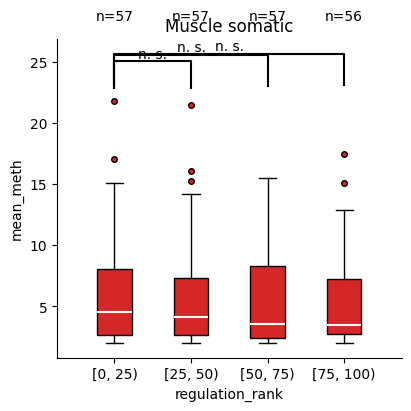

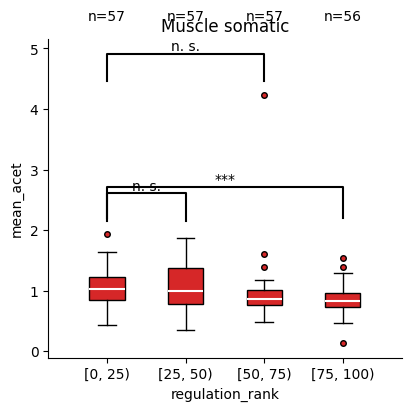

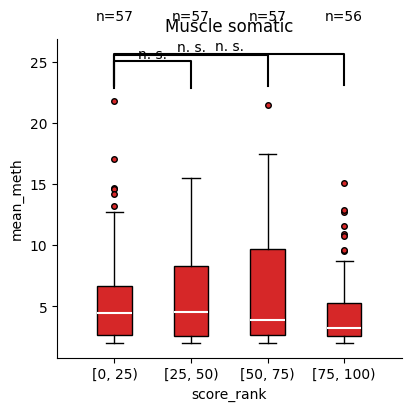

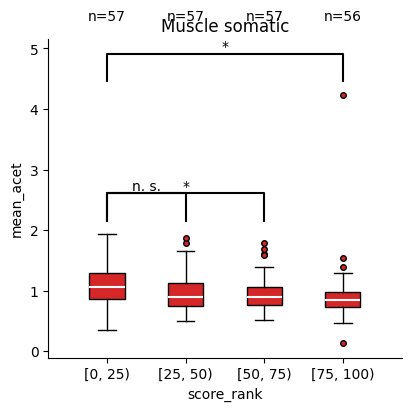

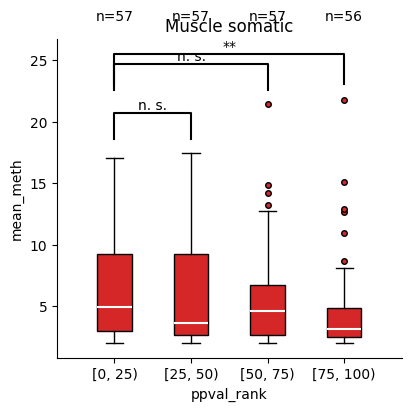

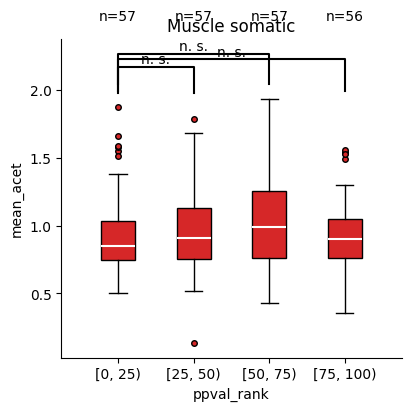

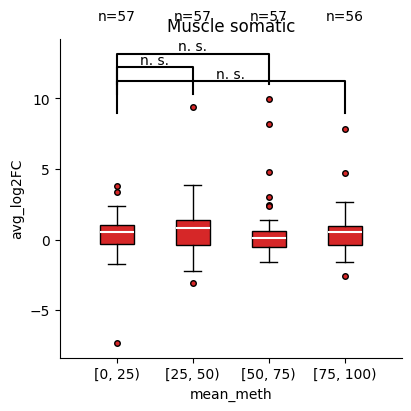

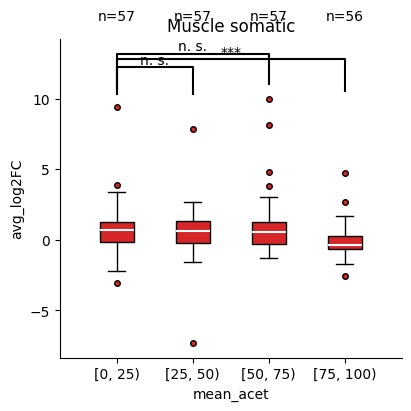

In [19]:
scit.set_defaults(figsize=(4,4))
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_meth', x_column='regulation_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_acet', x_column='regulation_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_meth', x_column='score_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_acet', x_column='score_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_meth', x_column='ppval_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', y_column='mean_acet', x_column='ppval_rank').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', x_column='mean_meth', y_column='avg_log2FC').savefig('/tmp/trash.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic', x_column='mean_acet', y_column='avg_log2FC').savefig('/tmp/trash.pdf')


In [20]:
df_muscle

gene_name,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean,mean_meth,mean_acet,ppval,score,p_val_mechange,lfc,base_mean,ppval_mechange,p_val_acetchange,lfc_acetchange,base_mean_acetchange,ppval_acetchange,regulation_rank,score_rank,ppval_rank
str,f64,f64,f64,f64,f64,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""snRNP-U1-C""",0.113148,1.061698,0.022,0.011,1.0,1.142479,2.380877,1.142479,0.946352,1.004739,0.89559,0.391442,0.8232808,0.047891,0.6746346,0.429558,1.0799077,0.170931,165.0,153.0,105.0
"""opa""",0.369574,-0.833694,0.006,0.013,1.0,1.031063,17.051292,1.031063,0.432299,-0.360405,1.0,-0.236732,14.148252,-0.0,0.137137,-0.360127,1.0051531,0.862846,25.0,57.0,51.0
"""E(spl)mgamma-HLH""",0.002997,3.053925,0.018,0.003,1.0,0.982533,7.807286,0.982533,2.523242,7.705791,0.589609,0.42306,1.9040552,0.229436,1.0,-0.049785,0.5868681,-0.0,219.0,208.0,179.0
"""mod(mdg4)""",0.049373,0.388421,0.088,0.064,1.0,0.993179,3.928625,0.993179,1.306515,0.507477,0.785856,0.349638,3.7983136,0.104657,1.0,0.071685,1.0062077,-0.0,111.0,139.0,130.0
"""CG11920""",0.000002,4.810741,0.022,0.001,0.02793,0.931474,5.337224,0.931474,5.738423,27.606067,1.0,0.025044,6.1129246,-0.0,0.8705723,0.2904364,1.0501819,0.060195,224.0,224.0,220.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Actbeta""",0.000658,-7.322786,0.0,0.012,1.0,0.901391,2.11639,0.901391,3.181632,-23.298412,0.2660566,0.58491,1.6084396,0.575026,0.497473,-0.276621,1.3911223,0.303231,1.0,1.0,189.0
"""zfh2""",0.038249,-0.295442,0.033,0.049,1.0,1.134652,14.210262,1.134652,1.41738,-0.418754,1.0,0.146326,4.419922,-0.0,0.00003,-1.984371,1.8894022,4.519219,73.0,52.0,139.0
"""myo""",0.031153,0.269446,0.137,0.103,1.0,1.582895,5.193419,1.582895,1.506505,0.405922,1.0,0.216775,2.3697479,-0.0,0.681166,-0.262581,0.7982333,0.166747,105.0,137.0,145.0


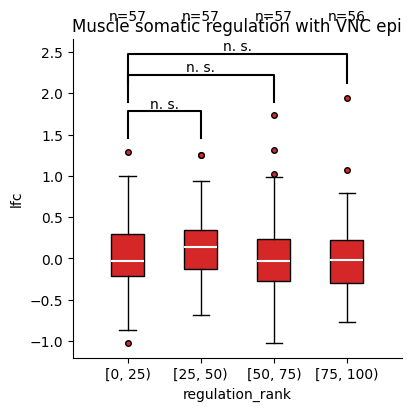

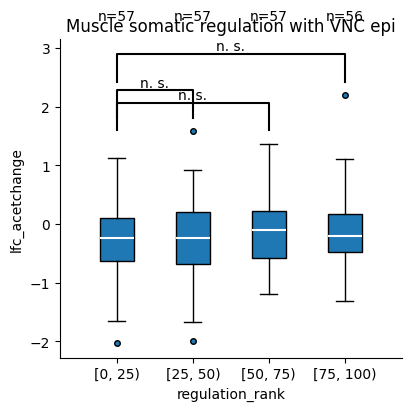

In [21]:

qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic regulation with VNC epi', x_column='regulation_rank', y_column='lfc').savefig('private/newest/figures/mechange_binned_lfc_hybrid_muscle.pdf')
qts(df_muscle, [25, 50, 75, 100], 'Muscle somatic regulation with VNC epi', x_column='regulation_rank', y_column='lfc_acetchange', color='tab:blue').savefig('private/newest/figures/acchange_binned_lfc_hybrid_muscle.pdf')

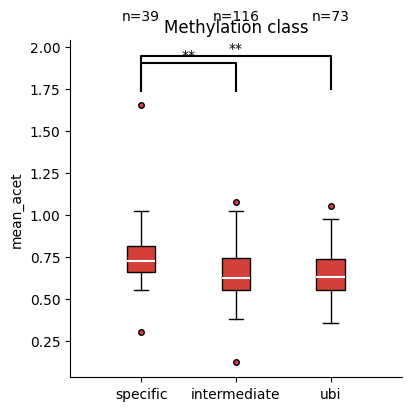

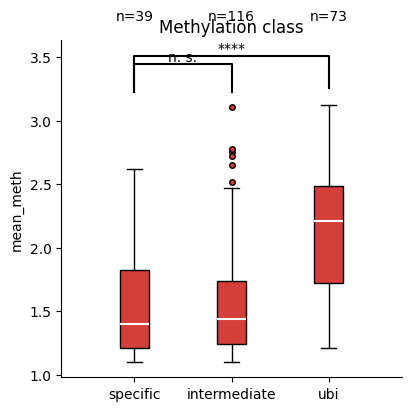

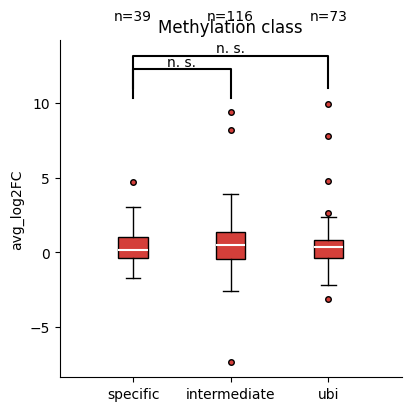

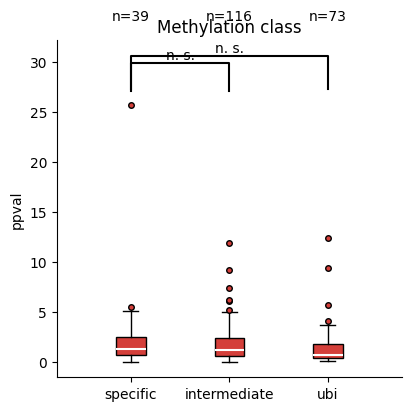

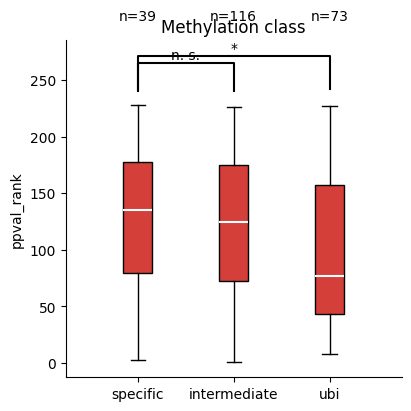

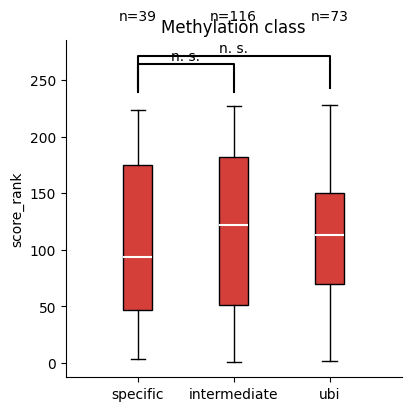

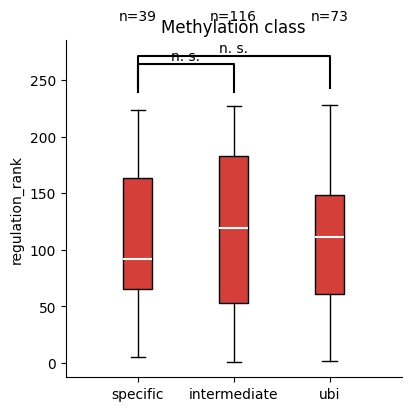

In [22]:
plot_classes(df_muscle, 'mean_acet', plotlabel='mean_acet', log_transform=True)
plot_classes(df_muscle, 'mean_meth', plotlabel='mean_meth', log_transform=True)
plot_classes(df_muscle, 'avg_log2FC', plotlabel='avg_log2FC', log_transform=False)
plot_classes(df_muscle, 'ppval', plotlabel='ppval', log_transform=False)
plot_classes(df_muscle, 'ppval_rank', plotlabel='ppval_rank', log_transform=False)
plot_classes(df_muscle, 'score_rank', plotlabel='score_rank', log_transform=False)
plot_classes(df_muscle, 'regulation_rank', plotlabel='regulation_rank', log_transform=False)

In [19]:
#mei = class_df.filter(pl.col('n') > 1, pl.col('n') < 5)['name'].to_numpy()
def get_clusters(_df, doprint: bool = False):
    clss = [me_class.filter(pl.col('n') == (i+1))['name'].to_numpy() for i in range(5)]
    dfs = [_df.filter(pl.col('gene_name').is_in(c)) for c in clss]
    if doprint:
        for i,d in enumerate(dfs):
            print(f"n={i+1} has {len(d['gene_name'].to_list())}")
            print(d['gene_name'].to_list())
    return dfs

df_sig = get_clusters(df_muscle.filter((pl.col('avg_log2FC'))>0.5,pl.col('p_val')<0.05),doprint=True)
df_nsig = get_clusters(df_muscle.filter(((pl.col('avg_log2FC'))<0.5).or_(pl.col('p_val')>0.05)))

n=1 has 10
['E(spl)mgamma-HLH', 'E(spl)m4-BFM', 'E(spl)m7-HLH', 'CG10254', 'E(spl)malpha-BFM', 'edl', 'l(2)k09913', 'Act57B', 'wal', 'Fib']
n=2 has 8
['CG7156', 'Tl', 'htl', 'Prx3', 'lov', 'CG1418', 'Kr', 'nrv2']
n=3 has 10
['14-3-3epsilon', 'CG7483', 'Dtg', 'nac', 'srp', 'Map205', 'COX7A', 'SmD1', 'Srp9', 'COX5B']
n=4 has 14
['Ipp', 'syd', 'EMC10', 'NAT1', 'Eglp4', 'vlc', 'l(2)09851', 'rb', 'CG11444', 'CG10602', 'CG31957', 'Pex19', 'CG6712', 'wg']
n=5 has 15
['CG11920', 'Abd-B', 'Hrb98DE', 'Noa36', 'CG33096', 'alph', 'CG12134', 'TER94', 'retn', 'MCTS1', 'gcm', 'drm', 'Idgf2', 'CG5888', 'Der-1']


In [20]:
# (me_class.join(meth_means_muscle, on='name').filter(pl.col('clusters').str.contains('Muscle'))['mean'] < 2).sum()

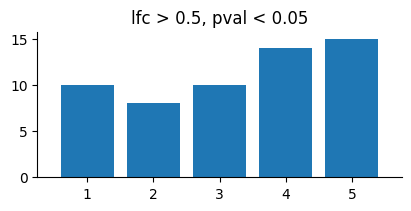

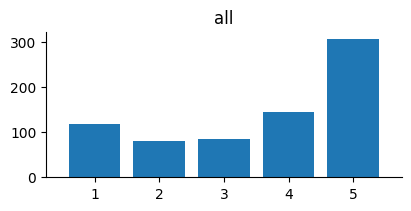

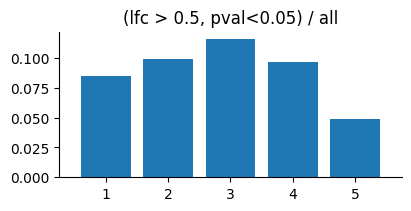

In [26]:
import matplotlib.pyplot as plt
scit.set_defaults(figsize=(4,2))
from src.plotting._helper import MplWrap
_df = me_class.filter(pl.col('clusters').str.contains('Muscle'))
_as= [
    np.array([len(d['gene_name'].to_list()) for d in df_sig]),
    # np.array([len(d['gene_name'].to_list()) for d in df_all])
    np.array([len(_df.filter(pl.col('n') == (i+1))['name'].to_numpy()) for i in range(5)])
]
titles = [
    'lfc > 0.5, pval < 0.05',
    'all'
]

for a,t in zip(_as, titles):
    plw = MplWrap(True)
    plw.ax.bar([i for i in range(5)],a)
    plw.set_text_xlabels([f"{i+1}" for i in range(5)], False)
    plw.despine()
    plw.ax.set_title(t)
    plw.fig.savefig(f'private/newest/figures/{t}_classanalysis.pdf')

plw = MplWrap(True)
plw.ax.bar([i for i in range(5)], [(_as[0][i]) / (_as[1][i]) for i in range(5)])
plw.set_text_xlabels([f"{i+1}" for i in range(5)], False)
plw.despine()
plw.ax.set_title("(lfc > 0.5, pval<0.05) / all")
plw.fig.savefig('private/newest/figures/ratio_classanalysis.pdf')

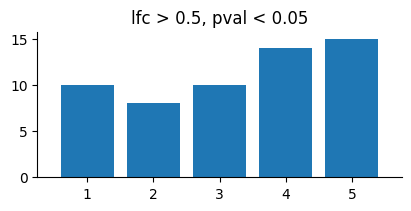

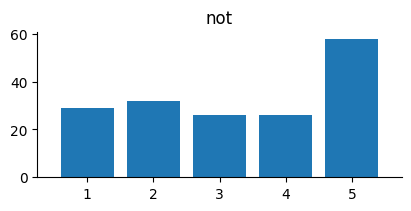

In [24]:
import matplotlib.pyplot as plt
scit.set_defaults(figsize=(4,2))
from src.plotting._helper import MplWrap
_as= [
    np.array([len(d['gene_name'].to_list()) for d in df_sig]),
    np.array([len(d['gene_name'].to_list()) for d in df_nsig])
]
titles = [
    'lfc > 0.5, pval < 0.05',
    'not'
]

for a,t in zip(_as, titles):
    plw = MplWrap(True)
    plw.ax.bar([i for i in range(5)],a)
    plw.set_text_xlabels([f"{i+1}" for i in range(5)], False)
    plw.despine()
    plw.ax.set_title(t)

7


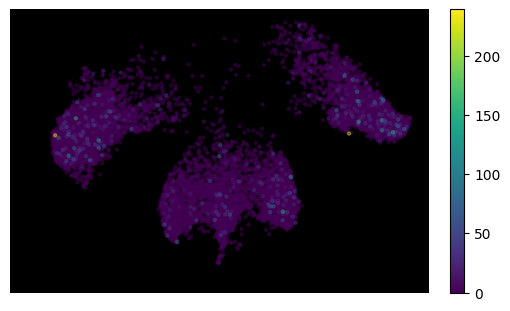

In [155]:
lc_active = scit.tl.make_layer_config('neighborhood_meth_active',in_obsm=True,feature_names=cttag.uns['neighborhood_acet_names'])

import pandas as pd
#gn = df.filter(pl.col('p_val_adj')<0.005).filter(pl.col('avg_log2FC')<-1)['gene_name'].to_numpy()
gn = 'Sox102F'
print(len(gn))

scit.set_defaults(figsize=(5,3))
#scit.tl.layer_pick_features(cttag, lc_meth, gn)
#scit.tl.copy_to_obs(cttag, lc_meth)
#scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True)
#
#scit.tl.layer_pick_features(cttag, lc_active, gn)
#scit.tl.copy_to_obs(cttag, lc_active)
#scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True)

scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(cttag, lc_acet, gn)
scit.tl.copy_to_obs(cttag, lc_acet)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True)

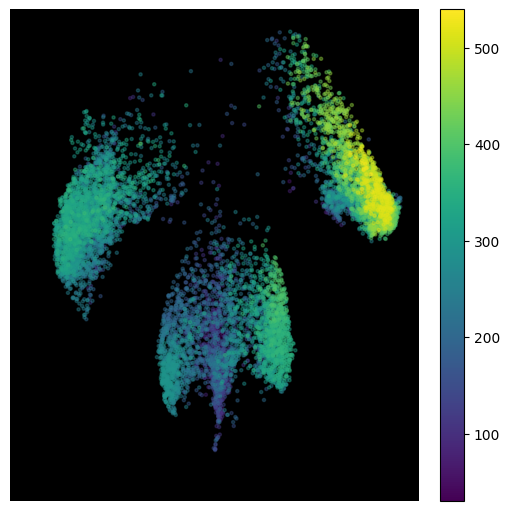

In [234]:

scit.tl.layer_pick_features(cttag, lc_active, np.ones(len(cttag.uns['gene_names_acet'],), dtype=np.bool_))
scit.tl.copy_to_obs(cttag, lc_active)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True)

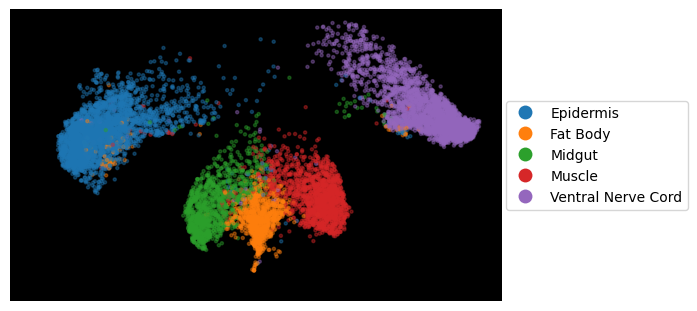

In [243]:

scit.pl.embedding2d(cttag, 'X_umap', 'label', size=5, alpha=0.4, black_background=True)